# 🦅 Huấn luyện Mô hình Multi-task BioListen VN trên Kaggle GPU

Notebook này dùng để huấn luyện mô hình phân loại đa tác vụ (Multi-task) BioListen VN sử dụng backbone **EfficientNet-V2-S** mạnh mẽ hơn trên GPU của Kaggle. Sau khi hoàn thành huấn luyện, mô hình sẽ tự động được chuyển đổi sang định dạng **ONNX** chuẩn hóa cho Backend.

### 🏷️ Cấu hình Nhãn Đầu ra:
1. **species_head (3 lớp phân nhóm sinh học):** Bird (0), Frog (1), Insect (2).
2. **human_head (9 lớp mối đe dọa):** 8 mối đe dọa (Fire, Chainsaw, Handsaw, Helicopter, VehicleEngine, Axe, Gunshot, Footsteps) + 1 nhãn Background.

In [1]:
# Cài đặt các thư viện cần thiết trên Kaggle
!pip install -q onnx onnxscript onnxruntime pandas tqdm matplotlib seaborn opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 9.0 MB/s eta 0:00:00


In [2]:
import os
import zipfile
import glob
import shutil
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[Setup] Sử dụng thiết bị: {device}")

[Setup] Sử dụng thiết bị: cuda


## 1. Tìm kiếm và Định vị Dữ liệu tự động trên Kaggle

Chúng ta tự động quét thư mục `/kaggle/input/` để định vị thư mục chứa fsc22 (đã giải nén tự động bởi Kaggle) và thư mục `grouping/` bất kể tên dataset bạn đặt trên Kaggle.

In [3]:
KAGGLE_INPUT_DIR = '/kaggle/input'
grouping_dir = None
fsc22_csv = None
local_fsc_pt_dir = None

# Quét thư mục đầu vào để tự động phát hiện đường dẫn
if os.path.exists(KAGGLE_INPUT_DIR):
    for root, dirs, files in os.walk(KAGGLE_INPUT_DIR):
        # 1. Tìm thư mục grouping
        if 'grouping' in dirs:
            grouping_dir = os.path.join(root, 'grouping')
        elif 'grouping' in root and grouping_dir is None:
            grouping_dir = root
            
        # 2. Tìm file metadata của fsc22
        for f in files:
            if 'fsc22_processed_metadata.csv' in f:
                fsc22_csv = os.path.join(root, f)
                
        # 3. Tìm thư mục chứa các file .pt của fsc22 (bằng cách tìm bất kỳ file .pt nào bắt đầu bằng số và không nằm trong grouping)
        if 'grouping' not in root:
            for f in files:
                if f.endswith('.pt') and '_' in f:
                    parts = f.split('_')
                    if parts[0].isdigit():
                        local_fsc_pt_dir = root
                        break

print("--- KẾT QUẢ QUÉT ĐƯỜNG DẪN INPUT ---")
print(f"Thư mục grouping: {grouping_dir}")
print(f"File metadata FSC22: {fsc22_csv}")
print(f"Thư mục chứa file .pt của FSC22: {local_fsc_pt_dir}")

if fsc22_csv and os.path.exists(fsc22_csv):
    if local_fsc_pt_dir is None:
        local_fsc_pt_dir = os.path.dirname(fsc22_csv)
    print(f"✓ Thư mục dữ liệu FSC22 đã sẵn sàng tại: {local_fsc_pt_dir}")
else:
    print("❌ Lỗi: Không tìm thấy file fsc22_processed_metadata.csv. Vui lòng kiểm tra lại dữ liệu tải lên Kaggle.")

--- KẾT QUẢ QUÉT ĐƯỜNG DẪN INPUT ---
Thư mục grouping: /kaggle/input/datasets/lenguyengiahung/biolistenvn/grouping
File metadata FSC22: /kaggle/input/datasets/qucvithunh/fsc22-processed-metadata/fsc22_processed_metadata.csv
Thư mục chứa file .pt của FSC22: /kaggle/input/datasets/qucvithunh/fsc22-processed
✓ Thư mục dữ liệu FSC22 đã sẵn sàng tại: /kaggle/input/datasets/qucvithunh/fsc22-processed


## 2. Xây dựng Dataset & Multi-task DataLoader

Chúng ta load trực tiếp các tệp `.pt` đã phân nhóm trong thư mục `grouping/` và các tệp đe dọa từ FSC22.

In [4]:
THREAT_CLASSES = [
    'Fire', 'Chainsaw', 'Handsaw', 'Helicopter', 'VehicleEngine',
    'Axe', 'Gunshot', 'Footsteps'
]
threat_to_idx = {name: idx for idx, name in enumerate(THREAT_CLASSES)}
BACKGROUND_CLASS_IDX = 8

class BioListenGroupedDataset(Dataset):
    def __init__(self, samples_list, fsc22_dir=None):
        self.samples = samples_list
        self.fsc22_dir = fsc22_dir

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        task_type = sample['task_type']

        if task_type == 'species':
            # Load trực tiếp file .pt từ grouping thư mục
            tensor = torch.load(sample['file_path'], map_location='cpu')
            
            species_label = torch.zeros(3)
            species_label[sample['class_idx']] = 1.0
            threat_label = BACKGROUND_CLASS_IDX

        elif task_type == 'human':
            # Load file từ FSC22
            fpath = os.path.join(self.fsc22_dir, sample['processed_pt_filename'])
            tensor = torch.load(fpath, map_location='cpu')
            
            species_label = torch.zeros(3)
            category = sample['Class Name']
            threat_label = threat_to_idx.get(category, BACKGROUND_CLASS_IDX)

        return tensor, species_label, threat_label, task_type

# Thu thập toàn bộ danh sách mẫu
all_train_samples = []
all_val_samples = []

# A. Lập chỉ mục thư mục grouping (Bird, Frog, Insect)
if grouping_dir and os.path.exists(grouping_dir):
    species_folders = ['Bird', 'Frog', 'Insect']
    species_samples = []
    
    for idx, folder in enumerate(species_folders):
        folder_path = os.path.join(grouping_dir, folder)
        if os.path.exists(folder_path):
            files = glob.glob(os.path.join(folder_path, '*.pt'))
            for f in files:
                species_samples.append({
                    'file_path': f,
                    'class_idx': idx,
                    'task_type': 'species'
                })
                
    # Phân tách Train / Val (80% / 20%)
    df_species = pd.DataFrame(species_samples)
    df_sp_train, df_sp_val = train_test_split(df_species, test_size=0.2, random_state=42)
    
    for _, row in df_sp_train.iterrows():
        all_train_samples.append(row.to_dict())
    for _, row in df_sp_val.iterrows():
        all_val_samples.append(row.to_dict())
        
    print(f"Nạp grouping species thành công: Train={len(df_sp_train)} | Val={len(df_sp_val)}")

# B. Lập chỉ mục FSC22 metadata
if fsc22_csv and os.path.exists(fsc22_csv):
    df_fsc = pd.read_csv(fsc22_csv)
    df_fsc_train, df_fsc_val = train_test_split(df_fsc, test_size=0.2, random_state=42)
    
    for _, row in df_fsc_train.iterrows():
        sample_dict = row.to_dict()
        sample_dict['task_type'] = 'human'
        all_train_samples.append(sample_dict)
        
    for _, row in df_fsc_val.iterrows():
        sample_dict = row.to_dict()
        sample_dict['task_type'] = 'human'
        all_val_samples.append(sample_dict)
        
    print(f"Nạp FSC22 thành công: Train={len(df_fsc_train)} | Val={len(df_fsc_val)}")

# Tạo Dataloader
train_dataset = BioListenGroupedDataset(all_train_samples, fsc22_dir=local_fsc_pt_dir)
val_dataset = BioListenGroupedDataset(all_val_samples, fsc22_dir=local_fsc_pt_dir)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f" DataLoader Khởi tạo xong: Train Batches={len(train_loader)} | Val Batches={len(val_loader)}")

Nạp grouping species thành công: Train=2172 | Val=544
Nạp FSC22 thành công: Train=1620 | Val=405
 DataLoader Khởi tạo xong: Train Batches=118 | Val Batches=30


## 3. Thiết kế Mô hình Multi-task (EfficientNet-V2-S)

Mô hình sử dụng backbone **EfficientNet-V2-S** được tối ưu hóa đặc biệt. Nhánh `species_head` có chiều ra là 3 nhãn lớn.

In [5]:
import torchvision.models as models

class BioListenMultiTaskModel(nn.Module):
    def __init__(self, num_species=3, num_threats=9, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_v2_s(weights=weights)
        
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()  # Loại bỏ classifier gốc

        # Nhánh 1: Phân loại Loài (species_head) - BCE
        self.species_head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_species)
        )

        # Nhánh 2: Nhận loại Mối đe dọa (human_head) - CrossEntropy
        self.human_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_threats)
        )

    def forward(self, x):
        features = self.backbone(x)  # Shape: (B, 1280)
        species_logits = self.species_head(features)
        threat_logits = self.human_head(features)
        return species_logits, threat_logits

model = BioListenMultiTaskModel(pretrained=True).to(device)
print("[OK] Mô hình EfficientNet-V2-S đã sẵn sàng.")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 155MB/s]


[OK] Mô hình EfficientNet-V2-S đã sẵn sàng.


## 4. Huấn luyện Mô hình với Adaptive Masked Loss & Early Stopping

Chúng ta huấn luyện tối đa 20 epochs kết hợp cơ chế dừng sớm (Early Stopping) với patience = 5 để tiết kiệm tài nguyên GPU.

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

def compute_multitask_loss(spec_logits, threat_logits, spec_labels, threat_labels, task_types):
    loss_species = nn.BCEWithLogitsLoss(reduction='none')(spec_logits, spec_labels)
    loss_human = nn.CrossEntropyLoss(reduction='none')(threat_logits, threat_labels)
    
    # Tạo masks dựa trên task_type
    spec_mask = torch.tensor([1.0 if t == 'species' else 0.0 for t in task_types], device=device)
    human_mask = torch.tensor([1.0 if t == 'human' else 0.0 for t in task_types], device=device)
    
    # Tính giá trị trung bình có trọng số
    loss_species_mean = (loss_species.mean(dim=1) * spec_mask).sum() / (spec_mask.sum() + 1e-9)
    loss_human_mean = (loss_human * human_mask).sum() / (human_mask.sum() + 1e-9)
    
    total_loss = loss_species_mean + loss_human_mean
    return total_loss, loss_species_mean, loss_human_mean

In [7]:
epochs = 100
patience = 10
patience_counter = 0
best_val_loss = float('inf')

history = {
    'train_loss': [], 'val_loss': [],
    'train_spec_loss': [], 'val_spec_loss': [],
    'train_human_loss': [], 'val_human_loss': []
}

os.makedirs('/kaggle/working/output', exist_ok=True)
output_path_pt = '/kaggle/working/output/best_model.pt'

for epoch in range(epochs):
    model.train()
    train_loss, train_spec, train_human = 0.0, 0.0, 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs:02d} [Train]")
    for tensors, spec_labels, threat_labels, task_types in pbar:
        tensors = tensors.to(device)
        spec_labels = spec_labels.to(device)
        threat_labels = threat_labels.to(device)
        
        optimizer.zero_grad()
        spec_logits, threat_logits = model(tensors)
        
        loss, l_spec, l_human = compute_multitask_loss(
            spec_logits, threat_logits, spec_labels, threat_labels, task_types
        )
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_spec += l_spec.item()
        train_human += l_human.item()
        
        pbar.set_postfix(loss=loss.item(), spec_l=l_spec.item(), human_l=l_human.item())
        
    scheduler.step()
    
    # Đánh giá trên tập Validation
    model.eval()
    val_loss, val_spec, val_human = 0.0, 0.0, 0.0
    with torch.no_grad():
        for tensors, spec_labels, threat_labels, task_types in val_loader:
            tensors = tensors.to(device)
            spec_labels = spec_labels.to(device)
            threat_labels = threat_labels.to(device)
            
            spec_logits, threat_logits = model(tensors)
            loss, l_spec, l_human = compute_multitask_loss(
                spec_logits, threat_logits, spec_labels, threat_labels, task_types
            )
            val_loss += loss.item()
            val_spec += l_spec.item()
            val_human += l_human.item()
            
    # Lưu lịch sử
    epoch_train_loss = train_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_spec_loss'].append(train_spec / len(train_loader))
    history['val_spec_loss'].append(val_spec / len(val_loader))
    history['train_human_loss'].append(train_human / len(train_loader))
    history['val_human_loss'].append(val_human / len(val_loader))
    
    print(f"==> Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    
    # Lưu Checkpoint tốt nhất và Dừng sớm
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), output_path_pt)
        print(f"[CHECKPOINT] Đã lưu trọng số tốt nhất vào: {output_path_pt}")
    else:
        patience_counter += 1
        print(f"[Early Stopping] Validation Loss không cải thiện trong {patience_counter} epochs liên tiếp.")
        if patience_counter >= patience:
            print(f"[Early Stopping] Kích hoạt dừng sớm tại Epoch {epoch+1}.")
            break

Epoch 01/100 [Train]: 100%|██████████| 118/118 [00:45<00:00,  2.59it/s, human_l=0.842, loss=0.991, spec_l=0.149]


==> Epoch 01 | Train Loss: 1.6044 | Val Loss: 0.5249
[CHECKPOINT] Đã lưu trọng số tốt nhất vào: /kaggle/working/output/best_model.pt


Epoch 02/100 [Train]: 100%|██████████| 118/118 [00:43<00:00,  2.74it/s, human_l=0.729, loss=0.925, spec_l=0.196]


==> Epoch 02 | Train Loss: 0.9215 | Val Loss: 0.3742
[CHECKPOINT] Đã lưu trọng số tốt nhất vào: /kaggle/working/output/best_model.pt


Epoch 03/100 [Train]: 100%|██████████| 118/118 [00:44<00:00,  2.64it/s, human_l=0.244, loss=0.462, spec_l=0.218]


...

==> Epoch 13 | Train Loss: 0.0375 | Val Loss: 0.3263
[Early Stopping] Validation Loss không cải thiện trong 8 epochs liên tiếp.


Epoch 14/100 [Train]: 100%|██████████| 118/118 [00:44<00:00,  2.65it/s, human_l=0.266, loss=0.266, spec_l=0.00075]


==> Epoch 14 | Train Loss: 0.0302 | Val Loss: 0.3336
[Early Stopping] Validation Loss không cải thiện trong 9 epochs liên tiếp.


Epoch 15/100 [Train]: 100%|██████████| 118/118 [00:44<00:00,  2.65it/s, human_l=0.00888, loss=0.0106, spec_l=0.00171]


==> Epoch 15 | Train Loss: 0.0291 | Val Loss: 0.3141
[Early Stopping] Validation Loss không cải thiện trong 10 epochs liên tiếp.
[Early Stopping] Kích hoạt dừng sớm tại Epoch 15.


## 5. Xuất báo cáo và Trực quan hóa Lịch sử Huấn luyện

Lưu đồ thị so sánh Loss và file dữ liệu `results.csv` phục vụ thống kê.

Đã lưu kết quả training vào: /kaggle/working/output/results.csv


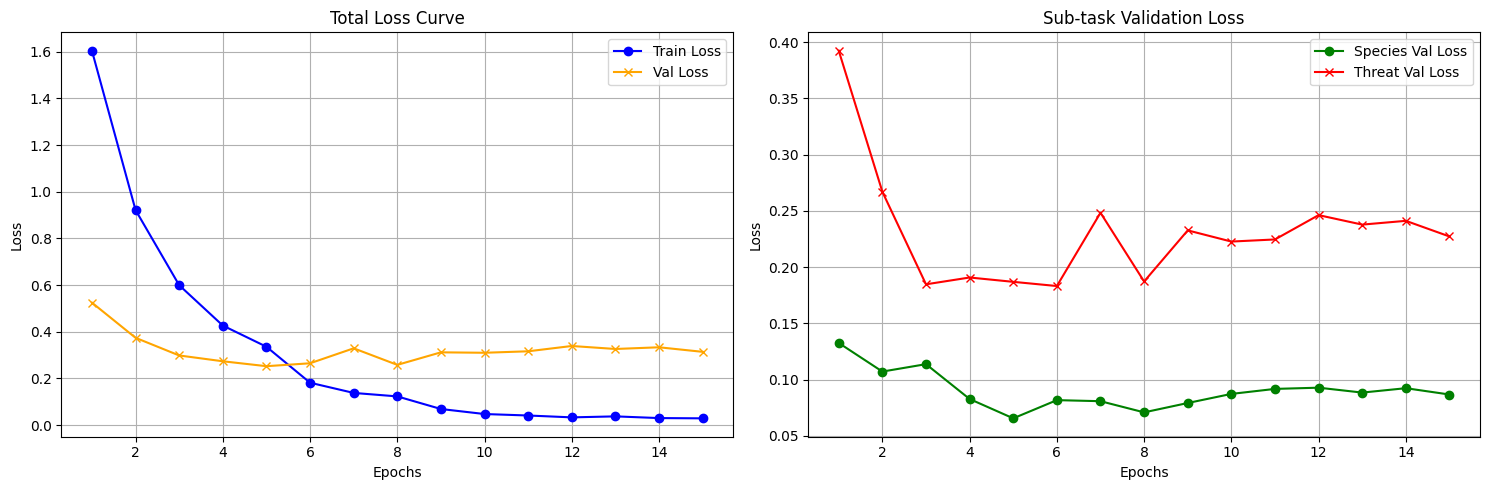

Đã lưu đồ thị so sánh Loss vào: /kaggle/working/output/loss_curves.png


In [8]:
# Lưu file kết quả CSV
df_results = pd.DataFrame(history)
csv_path = '/kaggle/working/output/results.csv'
df_results.to_csv(csv_path, index=False)
print(f"Đã lưu kết quả training vào: {csv_path}")

# Vẽ đồ thị Loss Curves (Sử dụng chiều dài thực tế của history đề phòng dừng sớm)
plt.figure(figsize=(15, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', color='orange', marker='x')
plt.title('Total Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['val_spec_loss'], label='Species Val Loss', color='green', marker='o')
plt.plot(epochs_range, history['val_human_loss'], label='Threat Val Loss', color='red', marker='x')
plt.title('Sub-task Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
img_path = '/kaggle/working/output/loss_curves.png'
plt.savefig(img_path)
plt.show()
print(f"Đã lưu đồ thị so sánh Loss vào: {img_path}")

## 6. Xuất mô hình sang định dạng ONNX hợp lệ cho Backend

Tích hợp Sigmoid cho Species và Softmax cho Human Threat trực tiếp vào đồ thị ONNX thông qua Wrapper.

In [9]:
class ONNXMultiTaskWrapper(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        self.model = trained_model

    def forward(self, x):
        species_logits, threat_logits = self.model(x)
        # Tích hợp hàm kích hoạt đầu ra vào ONNX Graph
        species_probs = torch.sigmoid(species_logits)
        threat_probs = torch.softmax(threat_logits, dim=1)
        return species_probs, threat_probs

print("Đang tiến hành chuyển đổi sang định dạng ONNX...")

# Nạp trọng số tốt nhất vào mô hình evaluation
eval_model = BioListenMultiTaskModel(pretrained=False).to('cpu')
eval_model.load_state_dict(torch.load(output_path_pt, map_location='cpu'))

wrapped_model = ONNXMultiTaskWrapper(eval_model)
wrapped_model.eval()

dummy_input = torch.randn(1, 3, 224, 224, dtype=torch.float32)
output_path_onnx = '/kaggle/working/output/model.onnx'

torch.onnx.export(
    wrapped_model,
    dummy_input,
    output_path_onnx,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['input_spectrogram'],
    output_names=['species_probabilities', 'threat_probabilities'],
    dynamic_axes={
        'input_spectrogram': {0: 'batch_size'},
        'species_probabilities': {0: 'batch_size'},
        'threat_probabilities': {0: 'batch_size'}
    }
)

print(f"✓ Đã xuất ONNX thành công: {output_path_onnx}")

# Kiểm tra lại độ hợp lệ của ONNX
try:
    import onnx
    onnx_model = onnx.load(output_path_onnx)
    onnx.checker.check_model(onnx_model)
    print("✓ File ONNX hợp lệ và graph syntax hoàn toàn chính xác!")
except Exception as e:
    print(f"❌ Có lỗi kiểm tra ONNX: {e}")

Đang tiến hành chuyển đổi sang định dạng ONNX...


/tmp/ipykernel_23/2838807293.py:25: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0718 23:43:22.669000 23 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0718 23:43:23.656000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, a

[torch.onnx] Obtain model graph for `ONNXMultiTaskWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ONNXMultiTaskWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Runtim

✓ Đã xuất ONNX thành công: /kaggle/working/output/model.onnx
✓ File ONNX hợp lệ và graph syntax hoàn toàn chính xác!


## 7. Giải thích mô hình bằng Grad-CAM (Explainable AI)

Vẽ biểu đồ nhiệt Grad-CAM trực tiếp trên dải melspectrogram đầu vào của mẫu kiểm tra.

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


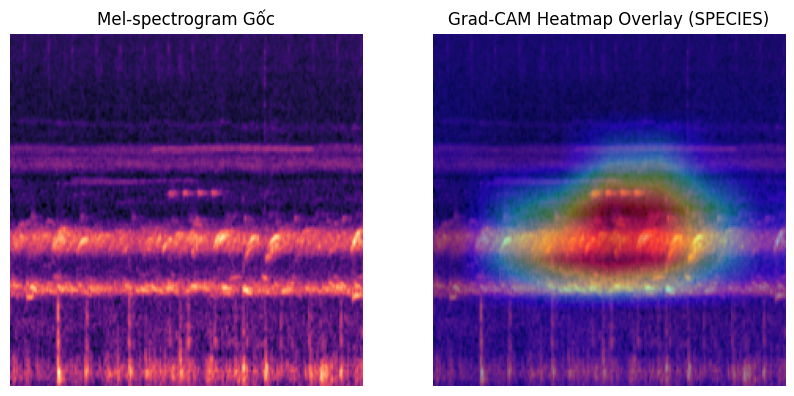

✓ Đã vẽ và lưu ảnh Grad-CAM mẫu thành công: /kaggle/working/output/gradcam_sample.png


In [10]:
class GradCAM:
    def __init__(self, target_model, target_layer):
        self.model = target_model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, task_type='human', target_class=0):
        self.model.eval()
        input_tensor = input_tensor.to(device).unsqueeze(0)
        spec_logits, threat_logits = self.model(input_tensor)

        score = spec_logits[0, target_class] if task_type == 'species' else threat_logits[0, target_class]
        
        self.model.zero_grad()
        score.backward()

        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))

        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        if cam.max() - cam.min() > 1e-9:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)
        return cam

try:
    target_conv_layer = model.backbone.features[-1]
    grad_cam = GradCAM(model, target_conv_layer)

    sample_tensor, spec_lbl, threat_lbl, task_type = val_dataset[0]
    target_idx = int(torch.argmax(spec_lbl)) if task_type == 'species' else int(threat_lbl)

    heatmap = grad_cam.generate_heatmap(sample_tensor, task_type=task_type, target_class=target_idx)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(sample_tensor[0].cpu().numpy(), cmap='magma', origin='lower')
    plt.title("Mel-spectrogram Gốc")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(sample_tensor[0].cpu().numpy(), cmap='magma', origin='lower')
    plt.imshow(heatmap_resized, cmap='jet', alpha=0.4, origin='lower')
    plt.title(f"Grad-CAM Heatmap Overlay ({task_type.upper()})")
    plt.axis('off')
    
    cam_img_path = '/kaggle/working/output/gradcam_sample.png'
    plt.savefig(cam_img_path)
    plt.show()
    print(f"✓ Đã vẽ và lưu ảnh Grad-CAM mẫu thành công: {cam_img_path}")
except Exception as e:
    print(f"Cảnh báo: Không chạy được Grad-CAM (yêu cầu GPU): {e}")

## 8. Đóng gói kết quả (Zip Output)

Tạo tệp nén `output.zip` chứa toàn bộ trọng số `.pt`, mô hình `.onnx`, báo cáo CSV và ảnh đồ thị để tải xuống máy local chỉ với 1 click.

In [11]:
output_dir = '/kaggle/working/output'
zip_output_path = '/kaggle/working/output.zip'

if os.path.exists(output_dir):
    print("Đang nén thư mục output thành tệp output.zip...")
    with zipfile.ZipFile(zip_output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(output_dir):
            for f in files:
                file_path = os.path.join(root, f)
                arcname = os.path.relpath(file_path, output_dir)
                zipf.write(file_path, arcname)
                
    print(f"✓ [THÀNH CÔNG] Đã tạo tệp zip thành công: {zip_output_path}")
    print("💡 Hướng dẫn: Bạn có thể click chuột phải vào file output.zip ở cột bên phải Colab/Kaggle để tải trực tiếp về máy local.")
else:
    print("❌ Lỗi: Thư mục output trống rỗng. Không có gì để nén.")

Đang nén thư mục output thành tệp output.zip...
✓ [THÀNH CÔNG] Đã tạo tệp zip thành công: /kaggle/working/output.zip
💡 Hướng dẫn: Bạn có thể click chuột phải vào file output.zip ở cột bên phải Colab/Kaggle để tải trực tiếp về máy local.
